# Data Mining Course Project

# Catherine Schrotberger DSC 550-T301 Summer 2025

## Milestone 1: Data Selection and EDA

Post-secondary education is at a unique point in this economy.  With tuition rates rising, universities want to be able to convince students to attend their location.  As students search for an institution, things they look at are location, degree programs offered, and cost.  With the goal being obtaining a degree at an appropriate cost.  Schools become less desirable when there is negative press or they have low or decreasing graduation rates.  To ensure that students meet their goals and universities are desirable to the next generation of students, they must maintain their graduation rates.  

Performance of students in education can be impacted by many outside factors.  Knowing a student’s background, initial performance, and economy they come from can help predict if they are likely to graduate.  In the secondary education environment, knowing what kinds of variables impact if someone will graduate can really help students and universities alike.  Being able to predict who might need assistance to graduate will increase graduation rates and provide students with backing and support.  The goal is to maintain or increase graduation rates.  

I found a data set on Kaggle that has been published as well.  It includes data from 2008-2019 from Europe in 17 undergraduate degree programs.  There is demographic, socioeconomic, and economic metrics available.  The target variable has the categorical options: Dropout, Enrolled, and Graduate.   As the goal of this project is to determine graduation success, those with an Enrolled status will be dropped from the analysis as their true outcome has not been determined yet.  There are 4,424 records in the data set.  

https://www.kaggle.com/datasets/thedevastator/higher-education-predictors-of-student-retention

In [1]:
# Import packages needed for analysis
import numpy as np
import pandas as pd
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import matplotlib.pyplot as plt
import seaborn as sns

### Import Data

In [3]:
# Import CSV to dataframe
students=pd.read_csv(r'G:/My Drive/College/Caitie/DSC550-T301/student_dataset.csv')
# Display first 5 rows of data
students.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


### Exploring the Data

Do a graphical analysis creating a minimum of four graphs. Label your graphs appropriately and explain/analyze the information provided by each graph. Your analysis should begin to answer the question(s) you are addressing. Write a short overview/conclusion of the insights gained from your graphical analysis.

In [5]:
students.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 35 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Nacionality                                     4424 non-null   int64  
 7   Mother's qualification                          4424 non-null   int64  
 8   Father's qualification                          4424 non-null   int64  
 9   Mother's occupation                      

The data set has 4,424 records and 35 columns.  Most of the fields are numeric (int64 or float64) with the exception of the target variable  which is currently of object format.

In [7]:
# Removing "Enrolled" target rows
students_data = students[students['Target'] !='Enrolled']
students_data.info()
# The new dataframe has 3,630 rows: 2,209 Graduate and 1,421 Dropouts

<class 'pandas.core.frame.DataFrame'>
Index: 3630 entries, 0 to 4423
Data columns (total 35 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  3630 non-null   int64  
 1   Application mode                                3630 non-null   int64  
 2   Application order                               3630 non-null   int64  
 3   Course                                          3630 non-null   int64  
 4   Daytime/evening attendance                      3630 non-null   int64  
 5   Previous qualification                          3630 non-null   int64  
 6   Nacionality                                     3630 non-null   int64  
 7   Mother's qualification                          3630 non-null   int64  
 8   Father's qualification                          3630 non-null   int64  
 9   Mother's occupation                           

In [9]:
# Add column where Graduate = 1 and Dropout = 0
students_data['Target_Int'] = students_data['Target'].apply(lambda x: 1 if x == 'Graduate' else 0)
# Update column names to remove '
students_data.rename(columns={"Father's qualification": "Dad qualification"}, inplace=True)
students_data.rename(columns={"Mother's qualification": "Mom qualification"}, inplace=True)
students_data.rename(columns={"Father's occupation": "Dad occupation"}, inplace=True)
students_data.rename(columns={"Mother's occupation": "Mom occupation"}, inplace=True)
students_data.rename(columns={"Daytime/evening attendance": "Attendance Time"}, inplace=True)
students_data.head()

C:\Users\caiti\AppData\Local\Temp\ipykernel_27084\2564270684.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  students_data['Target_Int'] = students_data['Target'].apply(lambda x: 1 if x == 'Graduate' else 0)
C:\Users\caiti\AppData\Local\Temp\ipykernel_27084\2564270684.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  students_data.rename(columns={"Father's qualification": "Dad qualification"}, inplace=True)
C:\Users\caiti\AppData\Local\Temp\ipykernel_27084\2564270684.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Data

,Marital status,Application mode,Application order,Course,Attendance Time,Previous qualification,Nacionality,Mom qualification,Dad qualification,Mom occupation,...,Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target,Target_Int
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout,0
1,1,6,1,11,1,1,1,1,3,4,...,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate,1
2,1,1,5,5,1,1,1,22,27,10,...,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout,0
3,1,8,2,15,1,1,1,23,27,6,...,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate,1
4,2,12,1,3,0,1,1,22,28,10,...,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate,1


### Visualization One

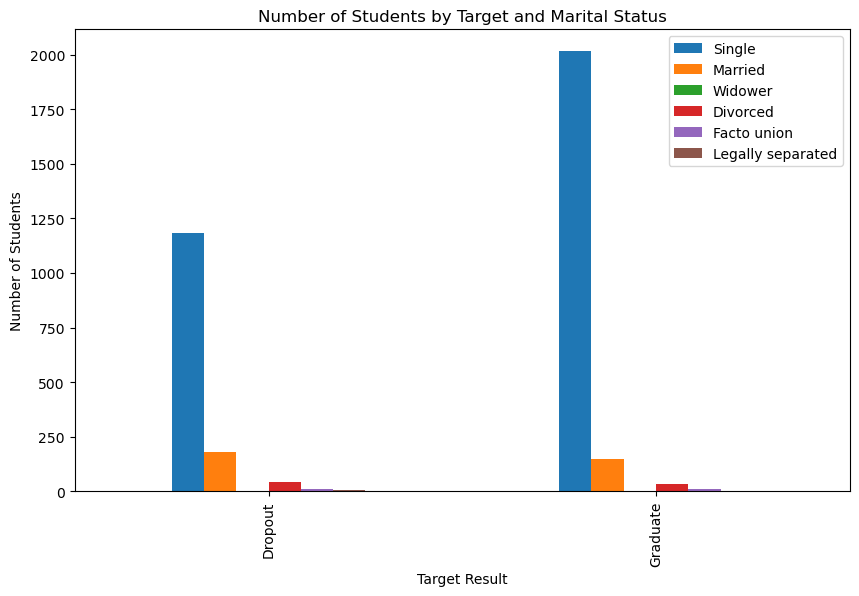

In [11]:
# Graph 1: Student marital status by Target
pivot_table = students_data.pivot_table(index='Target', columns='Marital status', values='Target_Int', aggfunc='count')
pivot_table.plot(kind='bar', figsize=(10, 6))
plt.title('Number of Students by Target and Marital Status')
plt.xlabel('Target Result')
plt.ylabel('Number of Students')
new_labels1 = ['Single', 'Married', 'Widower', 'Divorced', 'Facto union', 'Legally separated']
plt.legend(labels=new_labels1)
plt.show()

Based on this graph, the majority of students are single, with a greater proportion who graduate being single as well.

### Visualization Two

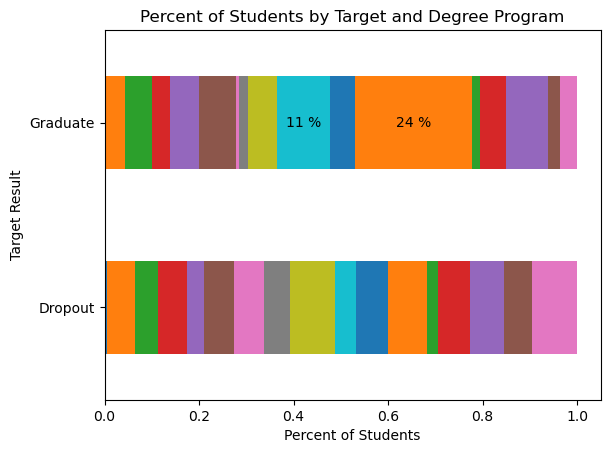

In [13]:
# Graph 2:  Percent of students by course and target
x_var, y_var = "Target", "Course"
df_grouped = students_data.groupby(x_var)[y_var].value_counts(normalize=True).unstack(y_var)
df_grouped.plot.barh(stacked=True, legend=False)
for ix, row in df_grouped.reset_index(drop=True).iterrows():
#    print(ix, row)
    cumulative = 0
    for element in row:
        if element == element and element > 0.1:
            plt.text(
                cumulative + element / 2,
                ix,
                f"{int(element * 100)} %",
                va="center",
                ha="center",
            )
        cumulative += element
plt.title('Percent of Students by Target and Degree Program')
plt.xlabel('Percent of Students')
plt.ylabel('Target Result')
plt.show()

The colors from left to right represent the following course programs, with the total number of students in the programs in ():
Biofuel Production Technologies (9), Animation and Multimedia Design (178), Social Service (evening attendance) (194), Agronomy (173), 
Communication Design(184), Veterinary Nursing (262), Informatics Engineering (106), Equiniculture (120), Management (272), Social Service (313), Tourism (211), Nursing (666), Oral Hygiene (69), Advertising and Marketing Management (220), Journalism and Communication (297), 
Basic Education (142), Management (evening attendance) (214).  Based on the small volumes, Biofuel Production Technologies doesn't visually show on the graph.

Twenty percent of those that graduate are in the Nursing program, followed 11% in Social Services.  For those that dropout, the distribution between programs appears more even.  This would als0 mean that a greater percentage of students in those programs graduate.

### Visualization Three

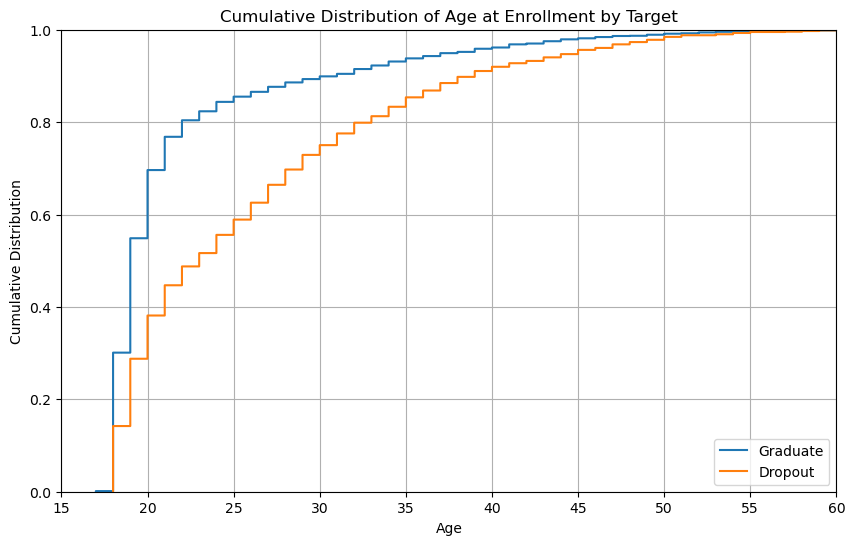

In [15]:
#Graph 3:  Cumulative Distribution Functions of Age by Target
student_data_filtered = students_data[['Target','Age at enrollment']]
sorted_multi = student_data_filtered.sort_values(by=['Target', 'Age at enrollment'])
sorted_multi = sorted_multi.sort_values(by=['Target', 'Age at enrollment'], ascending=[False, True])
# Plot CDF for 'Age at enrollment' split by 'Target'
plt.figure(figsize=(10, 6))
for day in sorted_multi['Target'].unique():
    subset = sorted_multi[sorted_multi['Target'] == day]
    sns.ecdfplot(data=subset, x="Age at enrollment", label=f'{day}')
plt.title('Cumulative Distribution of Age at Enrollment by Target')
plt.xlabel('Age')
plt.ylabel('Cumulative Distribution')
plt.legend(loc='lower right')
plt.xlim(15, 60)
plt.grid(True)
plt.show()

This graph shows that the younger a student enrolls in college the more likely they are to graduate.  For graduating students, over 50% had enrolled by age 20, while 50% of dropouts had enrolled by age 24.  Eighty percent of students who graduated had enrolled by age 23 where the 80% of the dropouts enrolled by age 33.  The curve of the dropouts is less sharp initially showing that those that dropout are likely to have started at an older age than those that graduate.

### Visualization Four

In [17]:
# Graph 4:  Target by Mother's Education Level
# The Education levels were very split out so I groupped them togheter for analysis purposes

def school_type(x):
    if x in [24, 25, 26, 27]:
        return '1-Elementary'
    elif x in [9, 18, 20, 21,28]:
        return '2-Middle School'
    elif x in [1, 7, 8, 10, 11, 12, 14, 15, 17, 19]:
        return '3-High School'
    elif x in [13, 16, 22, 23, 29, 31, 32]:
        return '4-Associate'
    elif x in [2, 3, 4, 5, 6, 30, 33, 34]:
        return '5-College'
    else:
        return 'Other'

mom_edu = students_data[['Target','Mom qualification']]
mom_edu['Mom School'] = mom_edu['Mom qualification'].apply(school_type)
mom_edu = mom_edu.sort_values(by=['Target', 'Mom School'], ascending=[False, True])
mom_edu.head()

C:\Users\caiti\AppData\Local\Temp\ipykernel_27084\2359691928.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mom_edu['Mom School'] = mom_edu['Mom qualification'].apply(school_type)


,Target,Mom qualification,Mom School
31,Graduate,27,1-Elementary
225,Graduate,25,1-Elementary
281,Graduate,24,1-Elementary
317,Graduate,26,1-Elementary
336,Graduate,26,1-Elementary


In [19]:
# Counts for each target and school level
pivot_table2 = mom_edu.pivot_table(index='Target', columns='Mom School', values='Mom qualification', aggfunc='count')
pivot_table2

Mom School,1-Elementary,2-Middle School,3-High School,4-Associate,5-College
Target,,,,,
Dropout,11,8,428,796,178
Graduate,13,7,622,1294,273


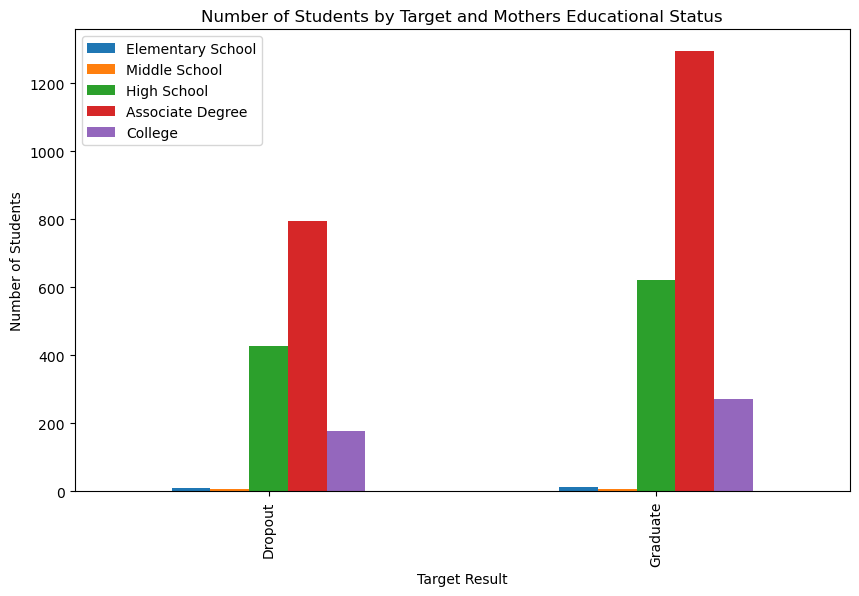

In [21]:
# Graphing target by mom educational type
pivot_table2.plot(kind='bar', figsize=(10, 6))
plt.title('Number of Students by Target and Mother''s Educational Status')
plt.xlabel('Target Result')
plt.ylabel('Number of Students')
new_labels1 = ['Elementary School', 'Middle School', 'High School', 'Associate Degree', 'College', 'Other']
plt.legend(labels=new_labels1)
plt.show()

The results between the target and the mother's educational status is very similar.  Those that graduate have 70.9% with mothers that had post-secondary education.  The dropouts only have 68.5% with mothers who have post-secondary education.  This means that the mother's educational background could influence if a student graduates or drops out.

### Visualization Five

In [23]:
# Graph 5:  Target by Father's Education Level
# The Education levels were very split out so I groupped them togheter for analysis purposes
dad_edu = students_data[['Target','Dad qualification']]
dad_edu['Dad School'] = dad_edu['Dad qualification'].apply(school_type)
dad_edu = dad_edu.sort_values(by=['Target', 'Dad School'], ascending=[False, True])
# Counts for each target and school level
pivot_table3 = dad_edu.pivot_table(index='Target', columns='Dad School', values='Dad qualification', aggfunc='count')
pivot_table3

C:\Users\caiti\AppData\Local\Temp\ipykernel_27084\1142464794.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dad_edu['Dad School'] = dad_edu['Dad qualification'].apply(school_type)


Dad School,1-Elementary,2-Middle School,3-High School,4-Associate,5-College
Target,,,,,
Dropout,520,176,567,16,142
Graduate,609,417,999,6,178


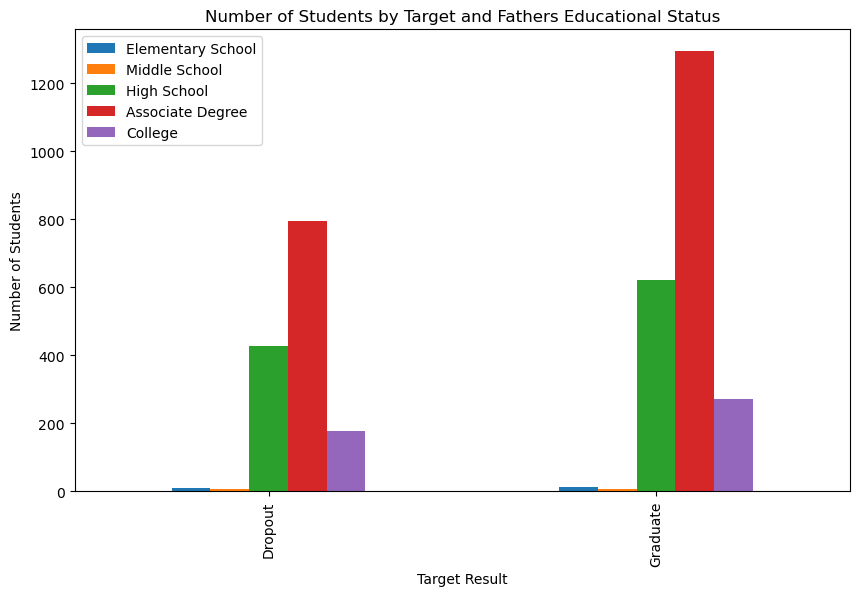

In [25]:
# Graphing target by mom educational type
pivot_table2.plot(kind='bar', figsize=(10, 6))
plt.title('Number of Students by Target and Father''s Educational Status')
plt.xlabel('Target Result')
plt.ylabel('Number of Students')
new_labels1 = ['Elementary School', 'Middle School', 'High School', 'Associate Degree', 'College', 'Other']
plt.legend(labels=new_labels1)
plt.show()

The results between the target and the father's educational status is very different - even different from the mother's educational status.  Those that graduate have 8.3% with fathers that had post-secondary education.  The dropouts only have 2.1% with fathers who have post-secondary education.  This means that the father's educational background could significantly influence if a student graduates or drops out.  Using both metrics together may work even better together.

## Milestone 2:  Data Preparation

### Data Preparation done in Milestone 1

Removed Enrolled student data because their data couldn't predict the outcome of Graduate or Dropout \
&emsp;&emsp;students_data = students[students['Target'] !='Enrolled'] \
Add column where Graduate = 1 and Dropout = 0 called Target_Int \
&emsp;&emsp;students_data['Target_Int'] = students_data['Target'].apply(lambda x: 1 if x == 'Graduate' else 0) \
Updated column names to remove ' \
&emsp;&emsp;students_data.rename(columns={"Father's qualification": "Dad qualification"}, inplace=True) \
&emsp;&emsp;students_data.rename(columns={"Mother's qualification": "Mom qualification"}, inplace=True) \
&emsp;&emsp;students_data.rename(columns={"Father's occupation": "Dad occupation"}, inplace=True) \
&emsp;&emsp;students_data.rename(columns={"Mother's occupation": "Mom occupation"}, inplace=True) \
&emsp;&emsp;students_data.rename(columns={"Daytime/evening attendance": "Attendance Time"}, inplace=True)

### Review Summary Statistics on Numerical Data

In [27]:
# Summary statistics of the numerical data
students_data[['Age at enrollment', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (credited)', 
               'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 
               'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 
               'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 
               'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 
               'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 
               'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP']].describe()

# Looked at raw data and there are 152 rows with no units for either semester, where the results are almost 50/50 graduate vs dropout.  
# Will remove those rows from data set since they are incomplete.  

,Age at enrollment,Curricular units 1st sem (credited),Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000
mean,23.461157,0.754270,0.754270,6.337466,8.071074,4.791460,10.534860,0.128926,0.581818,6.296419,7.763085,4.518457,10.036155,0.142149,11.630358,1.231598,-0.009256
std,7.827994,2.477277,2.477277,2.570773,4.286632,3.237845,5.057694,0.679111,2.022688,2.263020,3.964163,3.162376,5.481742,0.747670,2.667652,1.384911,2.259986
min,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,19.000000,0.000000,0.000000,5.000000,6.000000,3.000000,11.000000,0.000000,0.000000,5.000000,6.000000,2.000000,10.517857,0.000000,9.400000,0.300000,-1.700000
50%,20.000000,0.000000,0.000000,6.000000,8.000000,5.000000,12.341429,0.000000,0.000000,6.000000,8.000000,5.000000,12.333333,0.000000,11.100000,1.400000,0.320000
75%,25.000000,0.000000,0.000000,7.000000,10.000000,6.000000,13.500000,0.000000,0.000000,7.000000,10.000000,6.000000,13.500000,0.000000,13.900000,2.600000,1.790000
max,70.000000,20.000000,20.000000,26.000000,45.000000,26.000000,18.875000,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [29]:
# Removing no credit hour rows
students_data = students_data[students_data['Curricular units 1st sem (enrolled)'] !=0]
students_data.info()
# Removed 152 rows

<class 'pandas.core.frame.DataFrame'>
Index: 3478 entries, 1 to 4423
Data columns (total 36 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  3478 non-null   int64  
 1   Application mode                                3478 non-null   int64  
 2   Application order                               3478 non-null   int64  
 3   Course                                          3478 non-null   int64  
 4   Attendance Time                                 3478 non-null   int64  
 5   Previous qualification                          3478 non-null   int64  
 6   Nacionality                                     3478 non-null   int64  
 7   Mom qualification                               3478 non-null   int64  
 8   Dad qualification                               3478 non-null   int64  
 9   Mom occupation                                

In [31]:
# Rerunning statistics
students_data[['Age at enrollment', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (credited)', 
               'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 
               'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 
               'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 
               'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 
               'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 
               'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP']].describe()

,Age at enrollment,Curricular units 1st sem (credited),Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,3478.000000,3478.000000,3478.000000,3478.000000,3478.000000,3478.000000,3478.000000,3478.000000,3478.000000,3478.000000,3478.000000,3478.000000,3478.000000,3478.000000,3478.000000,3478.000000,3478.000000
mean,23.596895,0.787234,0.787234,6.614434,8.423807,5.000863,10.995268,0.134560,0.607246,6.571593,8.102358,4.715929,10.474768,0.148361,11.627717,1.235106,0.008856
std,7.930037,2.525712,2.525712,2.250616,4.025705,3.145544,4.651319,0.693249,2.062686,1.880502,3.694844,3.083226,5.173727,0.763234,2.669662,1.379361,2.263506
min,17.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,19.000000,0.000000,0.000000,6.000000,6.000000,3.000000,11.295833,0.000000,0.000000,6.000000,6.000000,3.000000,11.000000,0.000000,9.400000,0.300000,-1.700000
50%,20.000000,0.000000,0.000000,6.000000,8.000000,6.000000,12.500000,0.000000,0.000000,6.000000,8.000000,5.000000,12.400000,0.000000,11.100000,1.400000,0.320000
75%,26.000000,0.000000,0.000000,7.000000,10.000000,6.000000,13.500000,0.000000,0.000000,7.000000,10.000000,6.000000,13.540208,0.000000,13.900000,2.600000,1.790000
max,70.000000,20.000000,20.000000,26.000000,45.000000,26.000000,18.875000,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [33]:
# Apply the school grouping used during graphing to the full data set.
students_data['Mom School'] = students_data['Mom qualification'].apply(school_type)
students_data['Dad School'] = students_data['Dad qualification'].apply(school_type)
# Remove original columns
students_data = students_data.drop(['Dad qualification', 'Mom qualification'], axis=1)
students_data.head()

,Marital status,Application mode,Application order,Course,Attendance Time,Previous qualification,Nacionality,Mom occupation,Dad occupation,Displaced,...,Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target,Target_Int,Mom School,Dad School
1,1,6,1,11,1,1,1,4,4,1,...,6,13.666667,0,13.9,-0.3,0.79,Graduate,1,3-High School,5-College
2,1,1,5,5,1,1,1,10,10,1,...,0,0.000000,0,10.8,1.4,1.74,Dropout,0,4-Associate,1-Elementary
3,1,8,2,15,1,1,1,6,4,1,...,5,12.400000,0,9.4,-0.8,-3.12,Graduate,1,4-Associate,1-Elementary
4,2,12,1,3,0,1,1,10,10,0,...,6,13.000000,0,13.9,-0.3,0.79,Graduate,1,4-Associate,2-Middle School
5,2,12,1,17,0,12,1,10,8,0,...,5,11.500000,5,16.2,0.3,-0.92,Graduate,1,4-Associate,1-Elementary


In [35]:
# Create functions to update categorical variables to provide the value not a number

def yesno(x):
    if x in [0]:
        return 'no'
    elif x in [1]:
        return 'yes'
    else:
        return 'other'

def gender(x):
    if x in [0]:
        return 'female'
    elif x in [1]:
        return 'male'
    else:
        return 'other'

def attendance(x):
    if x in [0]:
        return 'evening'
    elif x in [1]:
        return 'daytime'
    else:
        return 'other'

def marital_status(x):
    if x in [1]:
        return 'single'
    elif x in [2]:
        return 'married'
    elif x in [3]:
        return 'widower'
    elif x in [4]:
        return 'divorced'
    elif x in [5,6]:
        return 'other'
    else:
        return 'other'

def nacionality(x):
    if x in [1]:
        return 'Portuguese'
    elif x in [3]:
        return 'Spanish'
    elif x in [9]:
        return 'Cape Verdean'
    elif x in [12]:
        return 'Santomean'
    elif x in [14]:
        return 'Braziliam'
    else:
        return 'Other'

def course(x):
    if x in [1]:
        return 'Biofuel Production Technologies'
    elif x in [2]:
        return 'Animation and Multimedia Design'
    elif x in [3,10]:
        return 'Social Service'
    elif x in [4]:
        return 'Agronomy'
    elif x in [5]:
        return 'Communication Design'
    elif x in [6]:
        return 'Veterinary Nursing'
    elif x in [7]:
        return 'Informatics Engineering'
    elif x in [8]:
        return 'Equiniculture'
    elif x in [9,17]:
        return 'Management'
    elif x in [11]:
        return 'Tourism'
    elif x in [12]:
        return 'Nursing'
    elif x in [13]:
        return 'Oral Hygiene'
    elif x in [14]:
        return 'Advertising and Marketing Management'
    elif x in [15]:
        return 'Journalism and Communication'
    elif x in [16]:
        return 'Basic Education'
    else:
        return 'other'

def prev_qual(x):
    if x in [13]:
        return '2-Middle School'
    elif x in [1, 7, 8, 9, 10, 11, 12, 14,]:
        return '3-High School'
    elif x in [16, ]:
        return '4-Associate'
    elif x in [2, 3, 4, 5, 6, 15, 17 ]:
        return '5-College'
    else:
        return 'Other'

def occupation(x):
    if x in [5, 22, 27, 28, 29]:
        return 'Adminitrative Support'
    elif x in [7, 34, 35, 43]:
        return 'Agriculture'
    elif x in [3, 19, 21]:
        return 'Education'
    elif x in [2,17]:
        return 'Executive'
    elif x in [20,24]:
        return 'Healthcare'
    elif x in [4, 23, 25, 26]:
        return 'Information Technology'
    elif x in [11, 14, 15, 16]:
        return 'Military'
    elif x in [6, 30, 32, 33]:
        return 'Personal Services'
    elif x in [18, 39, 45, 46]:
        return 'Service Industry'
    elif x in [1]:
        return 'Student'
    elif x in [40, 41, 42]:
        return 'Technical'
    elif x in [8, 9, 31, 36, 37, 38]:
        return 'Trades'
    else:
        return 'other'

In [37]:
students_data['Displaced'] = students_data['Displaced'].apply(yesno)
students_data['Educational special needs'] = students_data['Educational special needs'].apply(yesno)
students_data['Debtor'] = students_data['Debtor'].apply(yesno)
students_data['Tuition fees up to date'] = students_data['Tuition fees up to date'].apply(yesno)
students_data['Scholarship holder'] = students_data['Scholarship holder'].apply(yesno)
students_data['International'] = students_data['International'].apply(yesno)
students_data['Gender'] = students_data['Gender'].apply(gender)
students_data['Attendance Time'] = students_data['Attendance Time'].apply(attendance)
students_data['Marital status'] = students_data['Marital status'].apply(marital_status)
students_data['Nacionality'] = students_data['Nacionality'].apply(nacionality)
students_data['Course'] = students_data['Course'].apply(course)
students_data['Previous qualification'] = students_data['Previous qualification'].apply(prev_qual)
students_data['Mom occupation'] = students_data['Mom occupation'].apply(occupation)
students_data['Dad occupation'] = students_data['Dad occupation'].apply(occupation)
students_data.head()

,Marital status,Application mode,Application order,Course,Attendance Time,Previous qualification,Nacionality,Mom occupation,Dad occupation,Displaced,...,Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target,Target_Int,Mom School,Dad School
1,single,6,1,Tourism,daytime,3-High School,Portuguese,Information Technology,Information Technology,yes,...,6,13.666667,0,13.9,-0.3,0.79,Graduate,1,3-High School,5-College
2,single,1,5,Communication Design,daytime,3-High School,Portuguese,other,other,yes,...,0,0.000000,0,10.8,1.4,1.74,Dropout,0,4-Associate,1-Elementary
3,single,8,2,Journalism and Communication,daytime,3-High School,Portuguese,Personal Services,Information Technology,yes,...,5,12.400000,0,9.4,-0.8,-3.12,Graduate,1,4-Associate,1-Elementary
4,married,12,1,Social Service,evening,3-High School,Portuguese,other,other,no,...,6,13.000000,0,13.9,-0.3,0.79,Graduate,1,4-Associate,2-Middle School
5,married,12,1,Management,evening,3-High School,Portuguese,other,Trades,no,...,5,11.500000,5,16.2,0.3,-0.92,Graduate,1,4-Associate,1-Elementary


In [39]:
# Remove Application Mode because no dictionary to go with values and they must be international based as I can't understand them
# Remove Application order because the order in which they apply for classes as it relates to the student it unknown because there isn't a student ID
# Remove Target field as Target ID is the true target variable
students_data = students_data.drop(['Application mode', 'Application order','Target'], axis=1)
students_data.head()

,Marital status,Course,Attendance Time,Previous qualification,Nacionality,Mom occupation,Dad occupation,Displaced,Educational special needs,Debtor,...,Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target_Int,Mom School,Dad School
1,single,Tourism,daytime,3-High School,Portuguese,Information Technology,Information Technology,yes,no,no,...,6,6,13.666667,0,13.9,-0.3,0.79,1,3-High School,5-College
2,single,Communication Design,daytime,3-High School,Portuguese,other,other,yes,no,no,...,0,0,0.000000,0,10.8,1.4,1.74,0,4-Associate,1-Elementary
3,single,Journalism and Communication,daytime,3-High School,Portuguese,Personal Services,Information Technology,yes,no,no,...,10,5,12.400000,0,9.4,-0.8,-3.12,1,4-Associate,1-Elementary
4,married,Social Service,evening,3-High School,Portuguese,other,other,no,no,no,...,6,6,13.000000,0,13.9,-0.3,0.79,1,4-Associate,2-Middle School
5,married,Management,evening,3-High School,Portuguese,other,Trades,no,no,yes,...,17,5,11.500000,5,16.2,0.3,-0.92,1,4-Associate,1-Elementary


In [41]:
students_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3478 entries, 1 to 4423
Data columns (total 33 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  3478 non-null   object 
 1   Course                                          3478 non-null   object 
 2   Attendance Time                                 3478 non-null   object 
 3   Previous qualification                          3478 non-null   object 
 4   Nacionality                                     3478 non-null   object 
 5   Mom occupation                                  3478 non-null   object 
 6   Dad occupation                                  3478 non-null   object 
 7   Displaced                                       3478 non-null   object 
 8   Educational special needs                       3478 non-null   object 
 9   Debtor                                        

In [43]:
# Convert the categorical columns to dummy variables.
# Note - categorial fields were all assigned numbers with a reference/lookup table as to the actual values but still need to dummy them out for modeling because the numbers are not related.
cat_columns = ['Marital status', 'Course', 'Attendance Time', 'Previous qualification', 'Nacionality', 'Mom occupation', 'Dad occupation', 'Mom School', 'Dad School',
               'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'International']
students_encoded = pd.get_dummies(students_data, columns=cat_columns)
students_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3478 entries, 1 to 4423
Data columns (total 98 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Age at enrollment                               3478 non-null   int64  
 1   Curricular units 1st sem (credited)             3478 non-null   int64  
 2   Curricular units 1st sem (enrolled)             3478 non-null   int64  
 3   Curricular units 1st sem (evaluations)          3478 non-null   int64  
 4   Curricular units 1st sem (approved)             3478 non-null   int64  
 5   Curricular units 1st sem (grade)                3478 non-null   float64
 6   Curricular units 1st sem (without evaluations)  3478 non-null   int64  
 7   Curricular units 2nd sem (credited)             3478 non-null   int64  
 8   Curricular units 2nd sem (enrolled)             3478 non-null   int64  
 9   Curricular units 2nd sem (evaluations)        

In [45]:
# Perform feature reduction through PCA
from sklearn.decomposition import PCA

In [47]:
# Set PCA to retain variables that 98% of the variance is retained 
pca = PCA(n_components=0.98, whiten=True)
students_pca = pca.fit_transform(students_encoded)

In [49]:
# How many features are in the PCA-transformed matrix?
print("Original number of features:", students_encoded.shape[1])
print("Reduced number of features:", students_pca.shape[1]) 

Original number of features: 98
Reduced number of features: 19
